<a href="https://colab.research.google.com/github/OJB-Quantum/Monte-Carlo-Sim/blob/main/Monte_Carlo_Prediction_of_MoGe_Ti_Thin_Film_Critical_Temperature_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

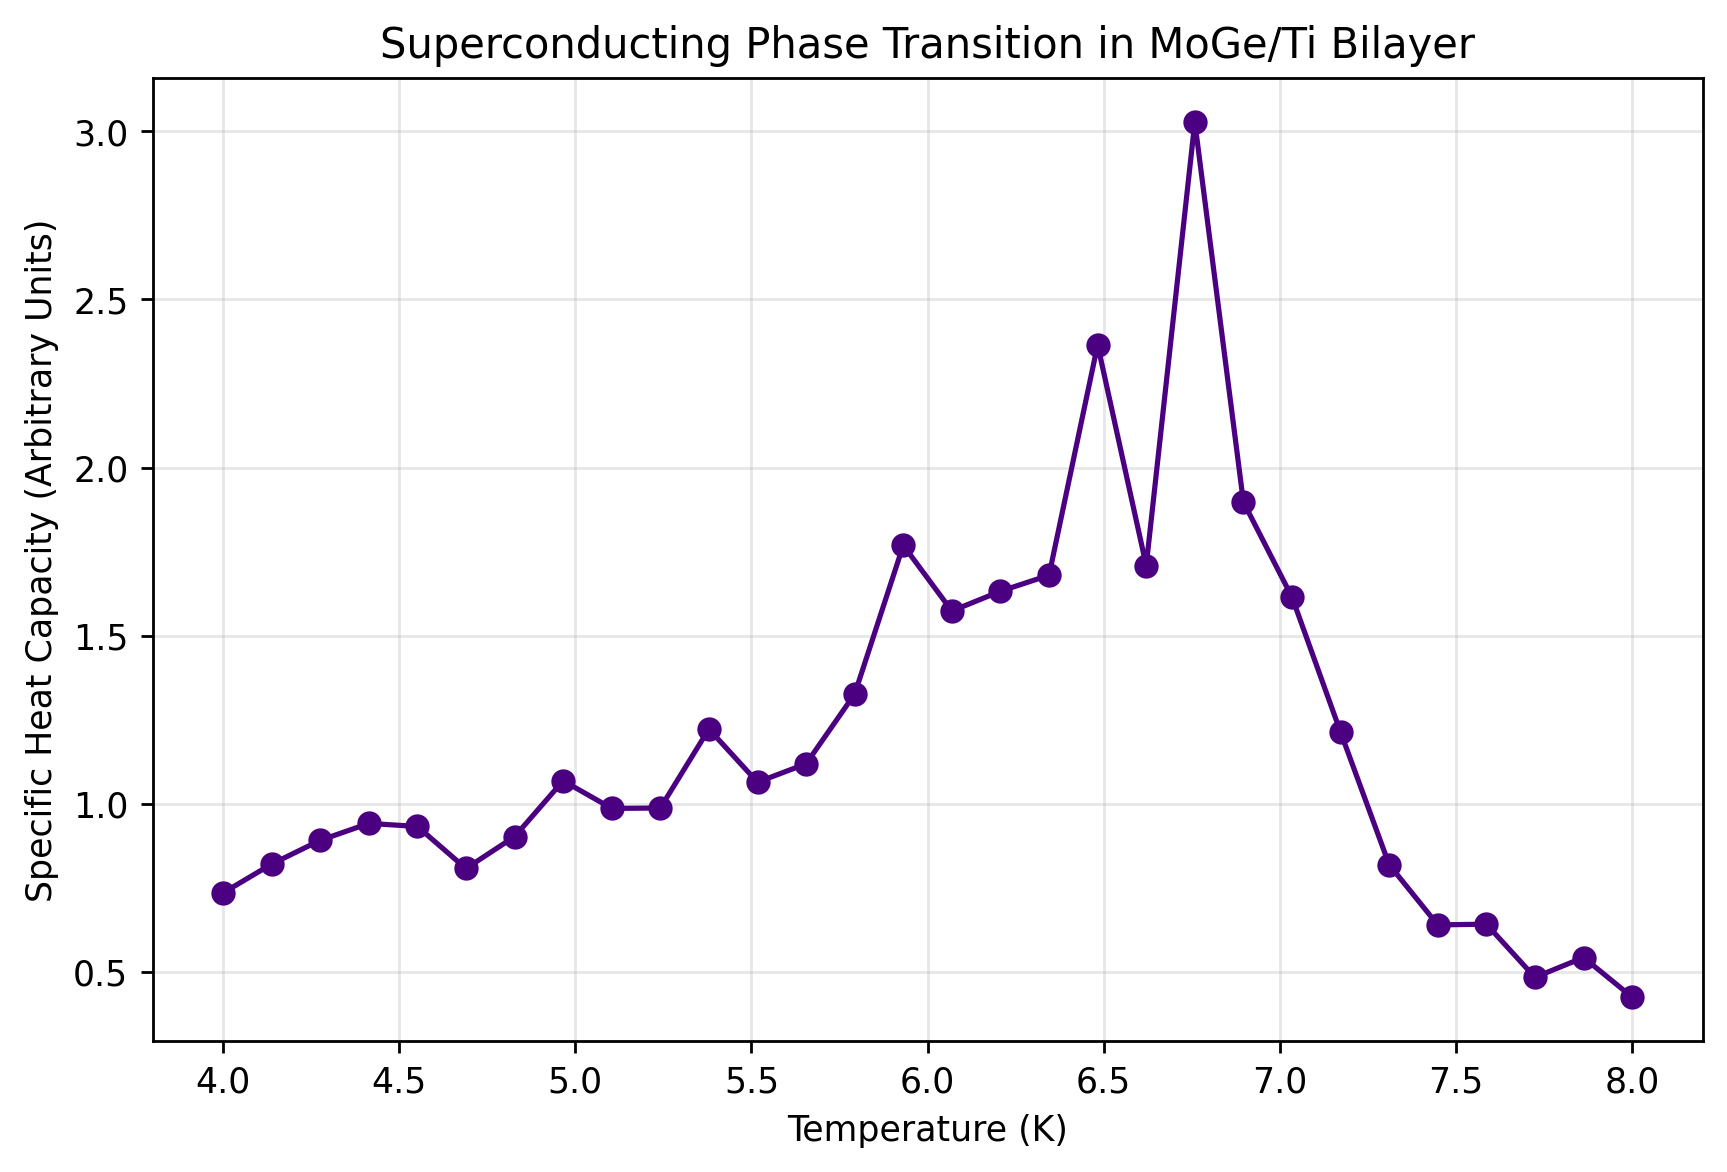

In [1]:
"""Predicts the critical temperature of a MoGe/Ti bilayer thin film.

This module implements a 3D classical XY model solved via a Metropolis-Hastings
Monte Carlo algorithm. The simulation identifies the phase transition
temperature via specific heat capacity divergence.
"""

import subprocess
import sys
from dataclasses import dataclass
from typing import List, Tuple

# Attempt to handle CuPy installation before importing
def ensure_gpu_dependencies() -> None:
    """Ensures required packages for GPU accelerated computing are installed."""
    try:
        import cupy
    except ImportError:
        print("CuPy not found. Attempting to install cupy-cuda12x...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "cupy-cuda12x"])

ensure_gpu_dependencies()

import cupy as cp
import matplotlib.pyplot as plt
import matplotlib as mpl

# Plotting configuration
mpl.rcParams.update({
    'font.sans-serif': ['Tahoma', 'DejaVu Sans'],
    'font.weight': 'normal',
    'figure.dpi': 250
})

@dataclass(frozen=True)
class SimulationConfig:
    """Configuration parameters for the bilayer simulation."""
    moge_thickness_nm: float = 200.0
    ti_thickness_nm: float = 5.0
    grid_spacing_nm: float = 5.0
    lattice_lateral_size: int = 16
    mc_sweeps: int = 2000
    equilibration_sweeps: int = 500
    temp_start: float = 4.0
    temp_end: float = 8.0
    temp_points: int = 30
    moge_bulk_tc: float = 7.0
    ti_bulk_tc: float = 0.4
    xy_scaling: float = 2.203

class Lattice:
    """Handles the construction of the 3D XY model coupling constants."""

    def __init__(self, config: SimulationConfig):
        """Initializes the coupling tensors.

        Args:
            config: A SimulationConfig object containing material parameters.
        """
        self.config = config
        self.layers_moge = int(config.moge_thickness_nm / config.grid_spacing_nm)
        self.layers_ti = int(config.ti_thickness_nm / config.grid_spacing_nm)
        self.total_layers = self.layers_moge + self.layers_ti

        self.j_xy, self.j_up, self.j_dn = self._setup_couplings()

    def _setup_couplings(self) -> Tuple[cp.ndarray, cp.ndarray, cp.ndarray]:
        """Calculates the interaction strengths J for different axes."""
        j_moge = self.config.moge_bulk_tc / self.config.xy_scaling
        j_ti = self.config.ti_bulk_tc / self.config.xy_scaling
        j_interface = cp.sqrt(j_moge * j_ti)

        # Lateral coupling (XY plane)
        j_xy = cp.zeros((self.total_layers, 1, 1), dtype=cp.float32)
        j_xy[:self.layers_ti] = j_ti
        j_xy[self.layers_ti:] = j_moge

        # Vertical coupling UP
        j_up = cp.zeros((self.total_layers, 1, 1), dtype=cp.float32)
        j_up[:self.layers_ti - 1] = j_ti
        j_up[self.layers_ti - 1] = j_interface
        j_up[self.layers_ti:-1] = j_moge
        j_up[-1] = 0.0

        # Vertical coupling DOWN
        j_dn = cp.zeros((self.total_layers, 1, 1), dtype=cp.float32)
        j_dn[1:] = j_up[:-1]
        j_dn[0] = 0.0

        return j_xy, j_up, j_dn

class MonteCarloSimulation:
    """Engine to run the Metropolis-Hastings simulation on the GPU."""

    def __init__(self, config: SimulationConfig, lattice: Lattice):
        """Args:
            config: Configuration parameters.
            lattice: The pre-computed Lattice couplings.
        """
        self.config = config
        self.lattice = lattice
        self.shape = (lattice.total_layers, config.lattice_lateral_size,
                      config.lattice_lateral_size)

        # Pre-compute checkerboard masks for parallel updates
        z, x, y = cp.meshgrid(
            cp.arange(self.shape[0]),
            cp.arange(self.shape[1]),
            cp.arange(self.shape[2]),
            indexing='ij'
        )
        self.even_mask = (z + x + y) % 2 == 0
        self.odd_mask = (z + x + y) % 2 == 1

    def run(self) -> Tuple[cp.ndarray, List[float]]:
        """Executes the simulation across a temperature range.

        Returns:
            A tuple containing the temperature array and a list of specific heats.
        """
        temperatures = cp.linspace(self.config.temp_start,
                                   self.config.temp_end,
                                   self.config.temp_points)
        specific_heats = []

        # Initial random state
        theta = cp.random.uniform(0, 2 * cp.pi, size=self.shape, dtype=cp.float32)

        for t in temperatures:
            specific_heats.append(self._simulate_at_temperature(t, theta))

        return temperatures, specific_heats

    def _simulate_at_temperature(self, t: float, theta: cp.ndarray) -> float:
        """Performs MC sweeps at a specific temperature.

        Args:
            t: Temperature in Kelvin.
            theta: Initial spin configuration.

        Returns:
            The calculated specific heat capacity.
        """
        energy_acc = 0.0
        energy_sq_acc = 0.0

        total_sweeps = self.config.mc_sweeps + self.config.equilibration_sweeps

        for sweep in range(total_sweeps):
            for mask in (self.even_mask, self.odd_mask):
                theta = self._metropolis_step(theta, mask, t)

            if sweep >= self.config.equilibration_sweeps:
                energy = self._calculate_total_energy(theta)
                energy_acc += energy
                energy_sq_acc += energy**2

        mean_e = energy_acc / self.config.mc_sweeps
        mean_e_sq = energy_sq_acc / self.config.mc_sweeps
        # Specific heat formula: C = (<E^2> - <E>^2) / (T^2 * N)
        heat_cap = (mean_e_sq - mean_e**2) / (t**2 * theta.size)
        return float(heat_cap.get())

    def _metropolis_step(self, theta: cp.ndarray, mask: cp.ndarray, t: float) -> cp.ndarray:
        """Updates spins using the Metropolis criterion.

        Args:
            theta: Current spins.
            mask: Boolean mask for checkerboard update.
            t: Temperature.

        Returns:
            Updated spin array.
        """
        delta_theta = cp.random.uniform(-cp.pi/2, cp.pi/2, size=theta.shape, dtype=cp.float32)
        theta_new = theta + delta_theta

        # Neighbors
        xp, xm = cp.roll(theta, -1, 1), cp.roll(theta, 1, 1)
        yp, ym = cp.roll(theta, -1, 2), cp.roll(theta, 1, 2)
        zp, zm = cp.roll(theta, -1, 0), cp.roll(theta, 1, 0)

        # Vectorized energy difference calculation
        e_old = (-self.lattice.j_xy * (cp.cos(theta - xp) + cp.cos(theta - xm) +
                                     cp.cos(theta - yp) + cp.cos(theta - ym))
                 - self.lattice.j_up * cp.cos(theta - zp)
                 - self.lattice.j_dn * cp.cos(theta - zm))

        e_new = (-self.lattice.j_xy * (cp.cos(theta_new - xp) + cp.cos(theta_new - xm) +
                                      cp.cos(theta_new - yp) + cp.cos(theta_new - ym))
                 - self.lattice.j_up * cp.cos(theta_new - zp)
                 - self.lattice.j_dn * cp.cos(theta_new - zm))

        delta_e = e_new - e_old
        acceptance = cp.exp(-delta_e / t)
        accept = (cp.random.rand(*theta.shape) < acceptance) & mask

        return cp.where(accept, theta_new, theta)

    def _calculate_total_energy(self, theta: cp.ndarray) -> cp.float32:
        """Calculates total system energy.

        Args:
            theta: Spin configuration.

        Returns:
            Total energy as a scalar.
        """
        xp = cp.roll(theta, -1, 1)
        yp = cp.roll(theta, -1, 2)
        zp = cp.roll(theta, -1, 0)

        energy = cp.sum(
            -self.lattice.j_xy * (cp.cos(theta - xp) + cp.cos(theta - yp))
            - self.lattice.j_up * cp.cos(theta - zp)
        )
        return energy

def plot_results(temperatures: cp.ndarray, specific_heats: List[float]) -> None:
    """Visualizes the simulation results.

    Args:
        temperatures: Array of temperatures.
        specific_heats: List of computed heat capacities.
    """
    plt.figure(figsize=(8, 5))
    plt.plot(temperatures.get(), specific_heats, marker='o',
             linestyle='-', color='indigo', markersize=6)
    plt.xlabel('Temperature (K)')
    plt.ylabel('Specific Heat Capacity (Arbitrary Units)')
    plt.title('Superconducting Phase Transition in MoGe/Ti Bilayer')
    plt.grid(True, alpha=0.3)
    plt.show()

def main() -> None:
    """Main execution entry point."""
    config = SimulationConfig()
    lattice = Lattice(config)
    sim = MonteCarloSimulation(config, lattice)

    temps, heats = sim.run()
    plot_results(temps, heats)

if __name__ == "__main__":
    main()
